# Multi-stream flow in a gas with a sinusoidal velocity profile

**Problem.** A gas of rigid spheres (mass $m$, radius $r$, number density $n$, temperature $T$)
is spatially uniform at $t=0$, but carries a macroscopic velocity along $x$,

$$v_x(x)\big|_{t=0} = v_0\sin (kx).$$

Find the condition on $v_0$ for a **multi-stream flow** to appear at some moment and some
place, where "multi-stream at $x$" means the local distribution $f(v_x)$ has at least two
local maxima, each at least **twice** the local minimum between them.
Assume $v_0\gg\sqrt{k_BT/m}$; an order-of-magnitude answer is enough.

---

## Answer

Two rates compete: the **steepening (wave-breaking) rate** $k v_0$ of the velocity profile,
and the **collision rate** $\nu\sim n\sigma \bar v$ of the gas. Multi-stream flow appears iff
steepening wins:

$$\boxed{\;v_0 \;\gtrsim\; \frac{\nu}{k}\;\sim\;\frac{n\sigma}{k}\sqrt{\frac{k_BT}{m}}
\;\sim\;\frac{n r^{2}}{k}\sqrt{\frac{k_BT}{m}}\;}$$

with $\sigma = \pi(2r)^2 = 4\pi r^2$ the hard-sphere cross-section. Equivalent ways to say it,
with $v_T\equiv\sqrt{k_BT/m}$, $\mathrm{Ma}=v_0/v_T$ and the mean free path
$\lambda = 1/(\sqrt2\,n\sigma)$:

$$k v_0 \gtrsim \nu \qquad\Longleftrightarrow\qquad
\mathrm{Ma}\cdot(k\lambda)\gtrsim 1\qquad\Longleftrightarrow\qquad
\lambda \gtrsim \underbrace{\frac{v_T}{k v_0}}_{\text{thickness of the fold}}$$

Together with the given $v_0 \gg v_T$ the full condition is
$v_0\gg v_T\max\!\left(1,\;1/(k\lambda)\right)$.
Keeping the hard-sphere prefactors, $\nu=\sqrt2\,n\sigma\bar v$ with
$\bar v=\sqrt{8k_BT/\pi m}$, gives $v_0\gtrsim 28\,n r^2 v_T/k$ — the numerical factor is
outside the accuracy of the estimate and is not part of the answer.

**Why.** Without collisions the gas free-streams, the profile steepens like a Burgers wave and
folds over (a caustic in phase space) at $t_b = 1/(kv_0)$ at $x=\pi/k$; the fold *is* the
multi-stream region, and (because $v_0\gg v_T$) it is resolved into separate peaks essentially
at $t_b$, at
$t_* = t_b\left[1+O\!\left((v_T/v_0)^{2/3}\right)\right]$.
Collisions destroy the fold, so multi-stream flow needs $\nu t_* \lesssim 1$, i.e. $kv_0\gtrsim\nu$.

## Contents

1. Notation and the three dimensionless groups
2. The collisionless (free-streaming) solution — exact
3. Cold-stream limit: Lagrangian map, fold, breaking time $t_b=1/(kv_0)$
4. The distribution at a fixed point: exact peak / dip geometry
5. The factor-of-two criterion $\Rightarrow$ $t_*=t_b\,[1+1.16\,\theta^{2/3}]$
6. How thick the fold is $\Rightarrow$ the length scale $v_T/(kv_0)$
7. Collisions $\Rightarrow$ the answer, with numbers for air
8. Which relative speed sets $\nu$, and how sharp the criterion is
9. Numerical verification: particle Monte Carlo with stochastic (BGK) collisions
10. **Alternative solution 2** — two-length-scale / shock-thickness argument (no PDE)
11. A caveat worth knowing: bimodal distributions inside *collisional* strong shocks
12. Summary

## 1. Notation and the three dimensionless groups

Thermal speed and hard-sphere kinetics:

$$v_T=\sqrt{\frac{k_BT}{m}},\qquad
\bar v=\sqrt{\frac{8k_BT}{\pi m}}=\sqrt{\tfrac{8}{\pi}}\,v_T,\qquad
\sigma=\pi(2r)^2=4\pi r^{2},$$

$$\lambda=\frac{1}{\sqrt2\,n\sigma}\quad(\text{mean free path}),\qquad
\nu=\frac{\bar v}{\lambda}=\sqrt2\,n\sigma\bar v\quad(\text{collision rate per molecule}).$$

Only the $x$-component of velocity matters: the $y,z$ components factor out of the
free-streaming problem, so we work with the marginal distribution $f(x,v_x,t)$, normalised so
that $\int f\,dv_x = n$ initially.

Dimensionless variables (length $1/k$, velocity $v_0$, time $1/(kv_0)$):

$$\xi=kx,\qquad V=\frac{v_x}{v_0},\qquad \tau=k v_0 t,\qquad
\theta=\frac{v_T}{v_0}=\frac{1}{\mathrm{Ma}}\ll1,\qquad
\Gamma=\frac{k v_0}{\nu}.$$

$\theta$ measures how cold the gas is compared with the flow; $\Gamma$ compares steepening
with collisions. The answer will be simply $\Gamma\gtrsim1$. A third group, the Knudsen
number $k\lambda$, is not independent: $\Gamma = \mathrm{Ma}\,(k\lambda)\,v_T/\bar v$.

### Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.dpi": 90, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.axisbelow": True, "figure.autolayout": True,
})

kB = 1.380649e-23

def gas(n, r, T, m):
    """Hard-sphere kinetic quantities (SI)."""
    sigma = 4 * np.pi * r ** 2
    vT = np.sqrt(kB * T / m)
    vbar = np.sqrt(8 * kB * T / (np.pi * m))
    lam = 1.0 / (np.sqrt(2) * n * sigma)
    nu = vbar / lam
    return dict(sigma=sigma, vT=vT, vbar=vbar, lam=lam, nu=nu)

# a reference "air-like" gas at room temperature
AIR = dict(n=2.5e25, r=1.5e-10, T=300.0, m=4.8e-26)
g = gas(**AIR)
print("reference gas (air-like, 300 K, 1 atm)")
print(f"  sigma = 4 pi r^2      = {g['sigma']:.3e} m^2")
print(f"  v_T   = sqrt(kT/m)    = {g['vT']:.1f} m/s")
print(f"  v_bar = sqrt(8kT/pi m)= {g['vbar']:.1f} m/s")
print(f"  lambda= 1/(sqrt2 n s) = {g['lam'] * 1e9:.1f} nm")
print(f"  nu    = v_bar/lambda  = {g['nu']:.3e} 1/s   (tau_coll = {1e12 / g['nu']:.1f} ps)")
print(f"  nu / (n r^2 v_T)      = {g['nu'] / (AIR['n'] * AIR['r'] ** 2 * g['vT']):.1f}"
      "   <- the hard-sphere prefactor in the boxed answer")

reference gas (air-like, 300 K, 1 atm)
  sigma = 4 pi r^2      = 2.827e-19 m^2
  v_T   = sqrt(kT/m)    = 293.8 m/s
  v_bar = sqrt(8kT/pi m)= 468.8 m/s
  lambda= 1/(sqrt2 n s) = 100.0 nm
  nu    = v_bar/lambda  = 4.686e+09 1/s   (tau_coll = 213.4 ps)
  nu / (n r^2 v_T)      = 28.4   <- the hard-sphere prefactor in the boxed answer


## 2. The collisionless solution — exact

The kinetic equation with no external force is

$$\frac{\partial f}{\partial t}+v_x\frac{\partial f}{\partial x}=C[f],$$

and $C[f]$ acts on the time scale $1/\nu$. Suppose first that $\nu$ is negligible
($C\equiv0$). Then $f$ is constant along straight lines $x-v_xt=\text{const}$:

$$f(x,v_x,t)=f_0\!\left(x-v_xt,\;v_x\right),\qquad
f_0(x,v)=\frac{n}{\sqrt{2\pi}\,v_T}\exp\!\left[-\frac{(v-v_0\sin kx)^2}{2v_T^{2}}\right].$$

(The initial state is a Maxwellian of uniform density and temperature, shifted locally by
the flow $v_0\sin kx$.) So the **exact** collisionless answer is

$$\boxed{f(x,v_x,t)=\frac{n}{\sqrt{2\pi}v_T}
\exp\!\left[-\frac{\left(v_x-v_0\sin\!\big(k(x-v_xt)\big)\right)^{2}}{2v_T^{2}}\right]}$$

or in dimensionless form, with $F = f\,v_0/n$,

$$F(V;\xi,\tau)=\frac{1}{\sqrt{2\pi}\,\theta}\,
e^{-H^{2}/2\theta^{2}},\qquad
\boxed{H(V;\xi,\tau)=V-\sin(\xi-V\tau)}$$

Everything below is geometry of the single function $H$: because $F$ is a monotone function
of $|H|$, the maxima of $F$ in $V$ sit exactly at the **zeros** of $H$, and the minima sit at
the **stationary points** of $H$.

In [2]:
def H(V, xi, tau):
    """H(V) = V - sin(xi - V tau); F = exp(-H^2/2 theta^2)/sqrt(2 pi)/theta."""
    return V - np.sin(xi - V * tau)

def F(V, xi, tau, theta):
    return np.exp(-H(V, xi, tau) ** 2 / (2 * theta ** 2)) / (np.sqrt(2 * np.pi) * theta)

# --- verification: does it solve  dF/dtau + V dF/dxi = 0 ?
theta = 0.05
h = 1e-5
rng = np.random.default_rng(0)
pts = []
while len(pts) < 6:                       # keep points where F is not astronomically small
    xi, V, tau = (rng.uniform(0, 2 * np.pi), rng.uniform(-1.2, 1.2),
                  rng.uniform(0.2, 1.8))
    if F(V, xi, tau, theta) > 1e-3:
        pts.append((xi, V, tau))
res = []
for xi, V, tau in pts:
    dt = (F(V, xi, tau + h, theta) - F(V, xi, tau - h, theta)) / (2 * h)
    dx = (F(V, xi + h, tau, theta) - F(V, xi - h, tau, theta)) / (2 * h)
    res.append(abs(dt + V * dx) / max(abs(dt), abs(V * dx), 1e-30))
print("free-streaming residual |F_tau + V F_xi| / scale at 6 random points"
      " (where F > 1e-3):")
print("   ", np.array2string(np.array(res), precision=2))
print(f"   max relative residual = {max(res):.2e}  (finite-difference truncation error)")

# --- verification: mass, momentum and energy of the exact solution
def moments(xig, tau, theta, vmax=6.0, nV=120001, chunk=40):
    """Density, momentum and energy density of the exact F, integrated over V."""
    Vg = np.linspace(-vmax, vmax, nV)
    out = np.empty((len(xig), 3))
    for i in range(0, len(xig), chunk):
        sl = slice(i, i + chunk)
        Fm = F(Vg[None, :], xig[sl, None], tau, theta)
        out[sl, 0] = np.trapezoid(Fm, Vg, axis=1)
        out[sl, 1] = np.trapezoid(Fm * Vg[None, :], Vg, axis=1)
        out[sl, 2] = np.trapezoid(Fm * Vg[None, :] ** 2, Vg, axis=1)
    return out.T

xig = np.linspace(0, 2 * np.pi, 721)[:-1]
for tau in [0.0, 0.7, 1.4]:
    dens, mom, ene = moments(xig, tau, theta)
    print(f"tau={tau:4.1f}:  <n> = {dens.mean():.6f}   "
          f"total momentum = {mom.mean():+.2e}   "
          f"total energy = {ene.mean():.6f}  (t=0 value {0.5 + theta ** 2:.6f})")

free-streaming residual |F_tau + V F_xi| / scale at 6 random points (where F > 1e-3):
    [2.31e-08 3.08e-11 3.43e-10 4.94e-08 3.20e-10 8.09e-10]
   max relative residual = 4.94e-08  (finite-difference truncation error)
tau= 0.0:  <n> = 1.000000   total momentum = +0.00e+00   total energy = 0.502500  (t=0 value 0.502500)
tau= 0.7:  <n> = 1.000000   total momentum = +0.00e+00   total energy = 0.502500  (t=0 value 0.502500)
tau= 1.4:  <n> = 1.000000   total momentum = -3.95e-17   total energy = 0.502500  (t=0 value 0.502500)


## 3. Cold-stream limit: the fold and the breaking time

Set $\theta\to0$ first (a genuinely cold gas). Then each molecule keeps the local flow
velocity of its starting point $\eta=kx_0$, and

$$V=\sin\eta,\qquad \xi=\eta+\tau\sin\eta .$$

This is the Lagrangian map of the free-streaming (or inviscid Burgers) problem
$\partial_t v_x+v_x\partial_x v_x=0$. It is invertible while

$$\frac{\partial\xi}{\partial\eta}=1+\tau\cos\eta>0 .$$

The Jacobian first vanishes at $\eta=\pi$, $\tau=1$: the profile breaks — the velocity
becomes triple-valued — at

$$\boxed{t_b=\frac{1}{k v_0}\quad\text{at}\quad x=\frac{\pi}{k}}$$

i.e. exactly where the initial shear $\partial_xv_x=v_0k\cos kx$ is most negative, as it must
be (a fluid element is compressed at rate $-\partial_x v_x$, and $1/|\partial_xv_x|_{\max}=1/(kv_0)$).
For $\tau>1$ three streams coexist in a window around $\xi=\pi$; the cold density
$\rho=\sum_j|1+\tau\cos\eta_j|^{-1}$ diverges at its edges (caustics).

cold-stream count around xi = pi at tau = 1.5:
   xi=2.600: 1 stream(s)
   xi=2.900: 3 stream(s)
   xi=3.000: 3 stream(s)
   xi=3.142: 3 stream(s)
   xi=3.300: 3 stream(s)
   xi=3.600: 1 stream(s)


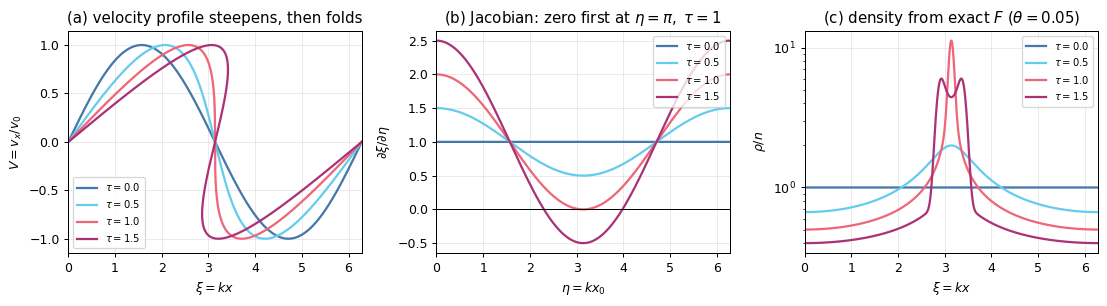

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12.4, 3.5))

eta = np.linspace(-np.pi, 3 * np.pi, 4001)
for tau, c in zip([0.0, 0.5, 1.0, 1.5], ["#4477aa", "#66ccee", "#ee6677", "#aa3377"]):
    xi = eta + tau * np.sin(eta)
    ax[0].plot(xi, np.sin(eta), color=c, lw=1.8, label=rf"$\tau={tau}$")
    ax[1].plot(eta, 1 + tau * np.cos(eta), color=c, lw=1.8, label=rf"$\tau={tau}$")
ax[0].set(xlim=(0, 2 * np.pi), ylim=(-1.15, 1.15), xlabel=r"$\xi=kx$",
          ylabel=r"$V=v_x/v_0$", title="(a) velocity profile steepens, then folds")
ax[0].legend(fontsize=8, loc="lower left")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xlim=(0, 2 * np.pi), xlabel=r"$\eta=kx_0$",
          ylabel=r"$\partial\xi/\partial\eta$", title=r"(b) Jacobian: zero first at $\eta=\pi,\ \tau=1$")
ax[1].legend(fontsize=8, loc="upper right")

# density of the warm gas, from the exact solution
xig = np.linspace(0, 2 * np.pi, 1201)
for tau, c in zip([0.0, 0.5, 1.0, 1.5], ["#4477aa", "#66ccee", "#ee6677", "#aa3377"]):
    dens = moments(xig, tau, 0.05, vmax=4.0, nV=80001)[0]
    ax[2].plot(xig, dens, color=c, lw=1.8, label=rf"$\tau={tau}$")
ax[2].set(xlim=(0, 2 * np.pi), xlabel=r"$\xi=kx$", ylabel=r"$\rho/n$", yscale="log",
          title=r"(c) density from exact $F$ ($\theta=0.05$)")
ax[2].legend(fontsize=8)
plt.show()

print("cold-stream count around xi = pi at tau = 1.5:")
for xi in [2.6, 2.9, 3.0, np.pi, 3.3, 3.6]:
    Vg2 = np.linspace(-1.4, 1.4, 400001)
    hh = H(Vg2, xi, 1.5)
    print(f"   xi={xi:5.3f}: {(np.diff(np.sign(hh)) != 0).sum()} stream(s)")

## 4. The distribution at a fixed point: exact peak and dip geometry

At fixed $\xi,\tau$ the shape of $F(V)$ is fixed by $H(V)=V-\sin(\xi-V\tau)$:

* **maxima of $F$** $\Leftrightarrow$ $H=0$ (the cold streams). Every one of them has the
  *same* height $F_{\max}=1/(\sqrt{2\pi}\theta)$ — a pretty feature of free streaming: each
  stream carries an undistorted copy of the initial Maxwellian.
* **minima of $F$** $\Leftrightarrow$ $H'(V)=1+\tau\cos(\xi-V\tau)=0$, with depth set by the
  value of $|H|$ there:
  $$\frac{F_{\max}}{F_{\min}}=\exp\!\left(\frac{H_{\rm ext}^{2}}{2\theta^{2}}\right).$$

Both are available in closed form. $H'=0$ means $\cos(\xi-V\tau)=-1/\tau$, i.e.
$\xi-V\tau=\pm\arccos(-1/\tau)$, and substituting back (write $X=\xi-\pi$):

$$\boxed{H_{\rm ext}^{(\mp)}=\frac{X\mp A(\tau)}{\tau},\qquad
A(\tau)=\sqrt{\tau^{2}-1}-\arccos\frac1\tau }$$

Two consequences, both exact:

* **the multi-stream window is $|X|<A(\tau)$.** Indeed a stream pair merges exactly when one
  extremum touches zero, $|X|=A$. So $A(\tau)$ *is* the half-width in $\xi$ of the
  three-stream region, and it opens as
  $A=\tfrac{2\sqrt2}{3}\varepsilon^{3/2}+O(\varepsilon^{5/2})$, $\varepsilon=\tau-1$ — the
  standard $3/2$ law of a fold ($A_3$) catastrophe.
* **the dips inside the fold are $|X\mp A|/\tau$**: at the centre $\xi=\pi$ both dips equal
  $A/\tau$, while approaching either edge one dip closes and the other deepens towards
  $2A/\tau$.

In [4]:
def A_fold(tau):
    """Half-width in xi of the 3-stream window; also tau * (central dip depth)."""
    tau = np.asarray(tau, dtype=float)
    return np.where(tau > 1, np.sqrt(np.maximum(tau ** 2 - 1, 0))
                    - np.arccos(np.clip(1 / tau, -1, 1)), 0.0)

print("exact check of the closed forms   (roots of H, dip depths)")
print(f"{'tau':>5} {'X/A':>6} {'#streams':>9} {'dips (numeric)':>28} {'dips (formula)':>28}")
Vg = np.linspace(-1.45, 1.45, 600001)
for tau in [1.02, 1.10, 1.50, 2.00]:
    A = float(A_fold(tau))
    for frac in [0.0, 0.5, 0.99, 1.01]:
        X = frac * A
        hh = H(Vg, np.pi + X, tau)
        nstream = int((np.diff(np.sign(hh)) != 0).sum())
        d = np.diff(hh)
        ext = np.where(np.sign(d[:-1]) != np.sign(d[1:]))[0] + 1
        num = np.sort(np.abs(hh[ext]))[:2]
        pred = np.sort([abs(X - A) / tau, abs(X + A) / tau])
        print(f"{tau:5.2f} {frac:6.2f} {nstream:9d}   "
              f"{np.array2string(num, precision=7, floatmode='fixed'):>26} "
              f"{np.array2string(pred, precision=7, floatmode='fixed'):>26}")
    print(f"      A({tau}) = {A:.6f}   (2sqrt2/3) eps^1.5 = "
          f"{2 * np.sqrt(2) / 3 * (tau - 1) ** 1.5:.6f}")

exact check of the closed forms   (roots of H, dip depths)
  tau    X/A  #streams               dips (numeric)               dips (formula)
 1.02   0.00         3        [0.0025912 0.0025912]      [0.0025912 0.0025912]
 1.02   0.50         3        [0.0012956 0.0038868]      [0.0012956 0.0038868]
 1.02   0.99         3   [2.5911669e-05 5.1564222e-03] [2.5911669e-05 5.1564222e-03]
 1.02   1.01         1   [2.5911670e-05 5.2082455e-03] [2.5911669e-05 5.2082455e-03]
      A(1.02) = 0.002643   (2sqrt2/3) eps^1.5 = 0.002667
 1.10   0.00         3        [0.0259617 0.0259617]      [0.0259617 0.0259617]
 1.10   0.50         3        [0.0129809 0.0389426]      [0.0129809 0.0389426]
 1.10   0.99         3        [0.0002596 0.0516638]      [0.0002596 0.0516638]
 1.10   1.01         1        [0.0002596 0.0521831]      [0.0002596 0.0521831]
      A(1.1) = 0.028558   (2sqrt2/3) eps^1.5 = 0.029814
 1.50   0.00         3        [0.1846435 0.1846435]      [0.1846435 0.1846435]
 1.50   0.50         3  

tau=1.05: peaks at V = [-0.5128  0.      0.5128], heights [7.9788 7.9788 7.9788] (all equal to 7.9788); contrast = 1.019
tau=1.2: peaks at V = [-0.8556  0.      0.8556], heights [7.9788 7.9788 7.9788] (all equal to 7.9788); contrast = 2.310
tau=1.5: peaks at V = [-0.9972  0.      0.9972], heights [7.9788 7.9788 7.9788] (all equal to 7.9788); contrast = 914.747


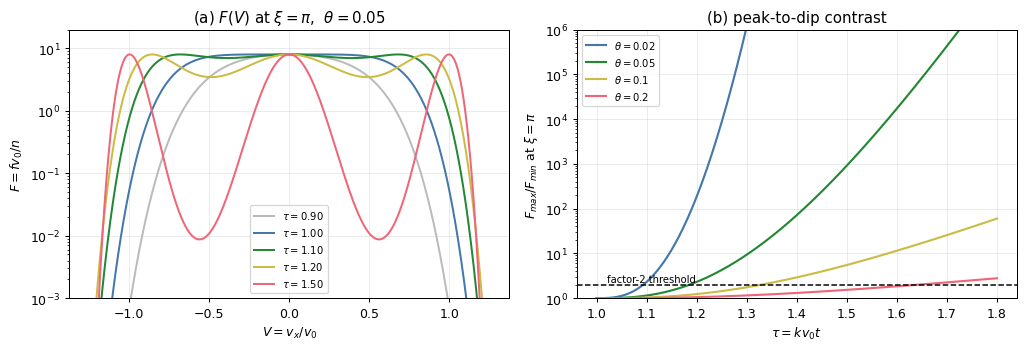

In [5]:
theta = 0.05
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))
Vg = np.linspace(-1.25, 1.25, 200001)
for tau, c in zip([0.90, 1.00, 1.10, 1.20, 1.50],
                  ["#bbbbbb", "#4477aa", "#228833", "#ccbb44", "#ee6677"]):
    ax[0].plot(Vg, F(Vg, np.pi, tau, theta), color=c, lw=1.6, label=rf"$\tau={tau:.2f}$")
ax[0].set(xlabel=r"$V=v_x/v_0$", ylabel=r"$F=f v_0/n$", yscale="log",
          ylim=(1e-3, 20), title=rf"(a) $F(V)$ at $\xi=\pi$,  $\theta={theta}$")
ax[0].legend(fontsize=8)

# contrast ratio at the centre of the fold vs tau, for several theta
taus = np.linspace(1.0, 1.8, 400)
for th, c in zip([0.02, 0.05, 0.10, 0.20], ["#4477aa", "#228833", "#ccbb44", "#ee6677"]):
    ax[1].plot(taus, np.exp((A_fold(taus) / taus) ** 2 / (2 * th ** 2)),
               color=c, lw=1.7, label=rf"$\theta={th}$")
ax[1].axhline(2, color="k", ls="--", lw=1.2)
ax[1].text(1.02, 2.3, "factor-2 threshold", fontsize=8)
ax[1].set(xlabel=r"$\tau=k v_0 t$", ylabel=r"$F_{max}/F_{min}$ at $\xi=\pi$",
          yscale="log", ylim=(1, 1e6), title="(b) peak-to-dip contrast")
ax[1].legend(fontsize=8)
plt.show()

for tau in [1.05, 1.2, 1.5]:
    Vg2 = np.linspace(-1.3, 1.3, 400001)
    f2 = F(Vg2, np.pi, tau, 0.05)
    d = np.diff(f2)
    imax = np.where((d[:-1] > 0) & (d[1:] <= 0))[0] + 1
    imin = np.where((d[:-1] < 0) & (d[1:] >= 0))[0] + 1
    print(f"tau={tau}: peaks at V = {np.round(Vg2[imax], 4)}, "
          f"heights {np.round(f2[imax], 4)} (all equal to "
          f"{1 / np.sqrt(2 * np.pi) / 0.05:.4f}); "
          f"contrast = {f2[imax].min() / f2[imin].max():.3f}")

tau=1.5: fold half-width A = 0.2770 rad; dips at centre = 0.1846, deepest available = 0.3693


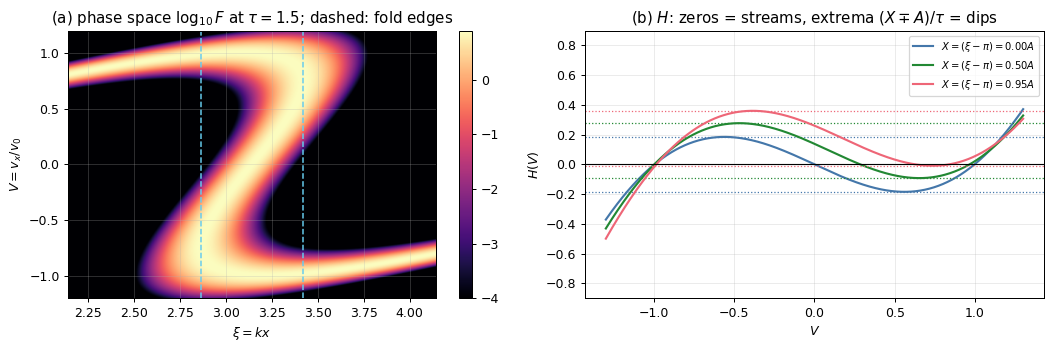

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11.8, 4.0))
theta, tau = 0.05, 1.5

xig = np.linspace(np.pi - 1.0, np.pi + 1.0, 500)
Vg = np.linspace(-1.2, 1.2, 500)
Fm = F(Vg[None, :], xig[:, None], tau, theta)
im = ax[0].imshow(np.log10(np.maximum(Fm.T, 1e-6)), origin="lower", aspect="auto",
                  extent=(xig[0], xig[-1], Vg[0], Vg[-1]), cmap="magma",
                  vmin=-4, vmax=np.log10(Fm.max()))
A = float(A_fold(tau))
for s in (-1, 1):
    ax[0].axvline(np.pi + s * A, color="#66ccee", ls="--", lw=1.2)
ax[0].set(xlabel=r"$\xi=kx$", ylabel=r"$V=v_x/v_0$",
          title=rf"(a) phase space $\log_{{10}}F$ at $\tau={tau}$; dashed: fold edges")
plt.colorbar(im, ax=ax[0])

Vg = np.linspace(-1.3, 1.3, 4001)
for frac, c in zip([0.0, 0.5, 0.95], ["#4477aa", "#228833", "#ee6677"]):
    X = frac * A
    ax[1].plot(Vg, H(Vg, np.pi + X, tau), color=c, lw=1.7,
               label=rf"$X=(\xi-\pi)={frac:.2f}A$")
    for lev in [(X + A) / tau, -(A - X) / tau]:       # the two extremal values of H
        ax[1].axhline(lev, color=c, ls=":", lw=1.0)
ax[1].axhline(0, color="k", lw=0.9)
ax[1].set(xlabel=r"$V$", ylabel=r"$H(V)$", ylim=(-0.9, 0.9),
          title=r"(b) $H$: zeros = streams, extrema $(X\mp A)/\tau$ = dips")
ax[1].legend(fontsize=8)
plt.show()
print(f"tau={tau}: fold half-width A = {A:.4f} rad; dips at centre = {A / tau:.4f}, "
      f"deepest available = {2 * A / tau:.4f}")

## 5. The factor-of-two criterion and the time it is first met

The criterion $F_{\max}\ge 2F_{\min}$ reads

$$\exp\!\left(\frac{H_{\rm ext}^{2}}{2\theta^{2}}\right)\ge2
\qquad\Longleftrightarrow\qquad
|H_{\rm ext}|\ \ge\ \theta\sqrt{2\ln2}\;=\;1.1774\,\theta .$$

Physically transparent: **two streams count as separate peaks once their velocity difference
exceeds the thermal width** — the dip depth $|H_{\rm ext}|$ is measured in units of $v_0$, and
$\theta = v_T/v_0$.

Using $|H_{\rm ext}| = A(\tau)/\tau$ at the centre of the fold (or $\to 2A(\tau)/\tau$ at its
edge, which is the most favourable point), and $A\simeq\frac{2\sqrt2}{3}\varepsilon^{3/2}$:

$$\varepsilon_*=\tau_*-1=\left(\frac{3\sqrt{\ln 2}}{2}\right)^{2/3}\theta^{2/3}
=1.160\,\theta^{2/3}\quad(\text{centre}),\qquad
\varepsilon_*=0.731\,\theta^{2/3}\quad(\text{best point in the fold}).$$

Either way the multi-stream condition is met a **relatively negligible** time after breaking:

$$\boxed{\;t_*=\frac{1}{kv_0}\left[1+O\!\left(\left(\frac{v_T}{v_0}\right)^{2/3}\right)\right]
\simeq\frac{1}{kv_0}\;}$$

This is exactly where the assumption $v_0\gg v_T$ is used: it guarantees (i) that the fold
appears before thermal spreading can smear the profile ($v_Tt_b = \theta/k \ll 1/k$), and
(ii) that the correction $\theta^{2/3}$ above is small, so the relevant time scale is just the
breaking time $t_b$. For $\theta=0.05$ ($\mathrm{Ma}=20$) the correction is $\sim16\%$.

asymptotic prefactors:  centre 1.1597,  fold edge 0.7305

   theta     Ma  eps* centre  1.160 th^2/3  eps* edge  0.731 th^2/3
  0.2000      5      0.64249       0.39660    0.32929       0.24984
  0.1000     10      0.32929       0.24984    0.18561       0.15739
  0.0500     20      0.18561       0.15739    0.10966       0.09915
  0.0200     50      0.09314       0.08545    0.05678       0.05383
  0.0100    100      0.05678       0.05383    0.03506       0.03391
  0.0010   1000      0.01173       0.01160    0.00736       0.00731
  0.0001  10000      0.00250       0.00250    0.00158       0.00157


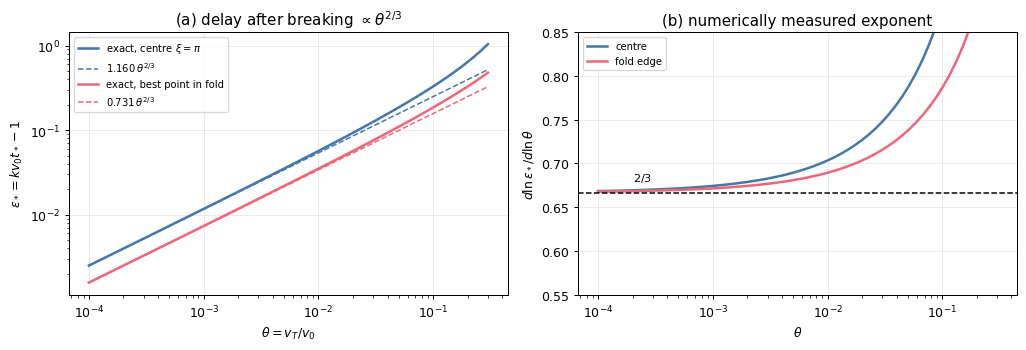

In [7]:
C2 = np.sqrt(2 * np.log(2))

def tau_star(theta, coef=1.0):
    """Smallest tau at which the factor-2 dip exists (coef=1 centre, 2 fold edge)."""
    lo, hi = 1.0, 4.0
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if coef * A_fold(mid) / mid < C2 * theta:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

thetas = np.logspace(-4, np.log10(0.3), 60)
e1 = np.array([tau_star(t, 1.0) - 1 for t in thetas])
e2 = np.array([tau_star(t, 2.0) - 1 for t in thetas])
p1 = (1.5 * np.sqrt(np.log(2))) ** (2 / 3)
p2 = (0.75 * np.sqrt(np.log(2))) ** (2 / 3)

print(f"asymptotic prefactors:  centre {p1:.4f},  fold edge {p2:.4f}")
print(f"\n{'theta':>8} {'Ma':>6} {'eps* centre':>12} {'1.160 th^2/3':>13}"
      f" {'eps* edge':>10} {'0.731 th^2/3':>13}")
for th in [0.2, 0.1, 0.05, 0.02, 0.01, 1e-3, 1e-4]:
    print(f"{th:8.4f} {1 / th:6.0f} {tau_star(th) - 1:12.5f} {p1 * th ** (2 / 3):13.5f}"
          f" {tau_star(th, 2) - 1:10.5f} {p2 * th ** (2 / 3):13.5f}")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax[0].loglog(thetas, e1, color="#4477aa", lw=2, label=r"exact, centre $\xi=\pi$")
ax[0].loglog(thetas, p1 * thetas ** (2 / 3), "--", color="#4477aa", lw=1.2,
             label=r"$1.160\,\theta^{2/3}$")
ax[0].loglog(thetas, e2, color="#ee6677", lw=2, label="exact, best point in fold")
ax[0].loglog(thetas, p2 * thetas ** (2 / 3), "--", color="#ee6677", lw=1.2,
             label=r"$0.731\,\theta^{2/3}$")
ax[0].set(xlabel=r"$\theta=v_T/v_0$", ylabel=r"$\varepsilon_*=k v_0 t_*-1$",
          title=r"(a) delay after breaking $\propto\theta^{2/3}$")
ax[0].legend(fontsize=8)

slope = np.gradient(np.log(e1), np.log(thetas))
ax[1].semilogx(thetas, slope, color="#4477aa", lw=2, label="centre")
ax[1].semilogx(thetas, np.gradient(np.log(e2), np.log(thetas)), color="#ee6677", lw=2,
               label="fold edge")
ax[1].axhline(2 / 3, color="k", ls="--", lw=1.2)
ax[1].text(2e-4, 0.68, r"$2/3$", fontsize=9)
ax[1].set(xlabel=r"$\theta$", ylabel=r"$d\ln\varepsilon_*/d\ln\theta$", ylim=(0.55, 0.85),
          title="(b) numerically measured exponent")
ax[1].legend(fontsize=8)
plt.show()

## 6. How thick the fold is: the length scale $v_T/(k v_0)$

Put $\varepsilon_*\sim\theta^{2/3}$ back into the fold width
$\Delta\xi = 2A \simeq \frac{4\sqrt2}{3}\varepsilon^{3/2}$:

$$\Delta\xi\big|_{\tau_*}\;\sim\;\theta
\qquad\Longrightarrow\qquad
\boxed{\;\Delta x_{\rm fold}\;\sim\;\frac{\theta}{k}=\frac{v_T}{k v_0}=v_T\,t_b\;}$$

The multi-stream region is *not* of wavelength size: at the moment it becomes visible it is
only as wide as the distance a thermal molecule drifts during the breaking time — smaller than
the wavelength by the factor $\theta=1/\mathrm{Ma}$. (Equivalently: the fold is the embryo of
a shock front, and this is its collisionless thickness.) This single length is what we must
compare with the mean free path in the next section, and it is the shortcut used in
**Alternative solution 2** below.

In [8]:
print(f"{'theta':>8} {'eps*':>9} {'fold width 2A (rad)':>21} {'2A/theta':>10}")
for th in [0.2, 0.1, 0.05, 0.02, 0.01, 1e-3, 1e-4]:
    for coef, name in [(1.0, "centre"), (2.0, "edge  ")]:
        ts = tau_star(th, coef)
        A = float(A_fold(ts))
        print(f"{th:8.4f} {ts - 1:9.5f} {2 * A:21.6f} {2 * A / th:10.3f}   ({name})")
print("\n=> the fold width at the detection time is ~1-2.5 x theta, i.e. Dx ~ v_T/(k v_0).")

   theta      eps*   fold width 2A (rad)   2A/theta
  0.2000   0.64249              0.773553      3.868   (centre)
  0.2000   0.32929              0.313023      1.565   (edge  )
  0.1000   0.32929              0.313023      3.130   (centre)
  0.1000   0.18561              0.139595      1.396   (edge  )
  0.0500   0.18561              0.139595      2.792   (centre)
  0.0500   0.10966              0.065326      1.307   (edge  )
  0.0200   0.09314              0.051483      2.574   (centre)
  0.0200   0.05678              0.024885      1.244   (edge  )
  0.0100   0.05678              0.024885      2.489   (centre)
  0.0100   0.03506              0.012187      1.219   (edge  )
  0.0010   0.01173              0.002382      2.382   (centre)
  0.0010   0.00736              0.001186      1.186   (edge  )
  0.0001   0.00250              0.000236      2.361   (centre)
  0.0001   0.00158              0.000118      1.179   (edge  )

=> the fold width at the detection time is ~1-2.5 x theta, i.e. D

## 7. Collisions: the answer

Everything above assumed free streaming. Collisions restore a *local* Maxwellian, which by
definition has a single maximum: they are what forbids multi-stream flow. Each molecule
suffers collisions at rate $\nu=\bar v/\lambda=\sqrt2\,n\sigma\bar v$, so the number of
collisions before the fold becomes visible is

$$N_{\rm coll}=\nu\,t_*\simeq\frac{\nu}{k v_0}=\frac1\Gamma .$$

**Multi-stream flow arises iff $N_{\rm coll}\lesssim1$:**

$$\Gamma=\frac{k v_0}{\nu}\gtrsim1
\qquad\Longleftrightarrow\qquad
v_0\gtrsim\frac{\nu}{k}=\frac{\sqrt2\,n\sigma\bar v}{k}
\;\sim\;\frac{n r^{2}}{k}\sqrt{\frac{k_BT}{m}} .$$

Three equivalent readings of the same inequality:

| form | meaning |
|---|---|
| $k v_0\gtrsim\nu$ | steepening rate beats the collision rate |
| $\mathrm{Ma}\,(k\lambda)\gtrsim1$, i.e. $v_0\gtrsim v_T/(k\lambda)$ | Mach number beats the inverse Knudsen number |
| $\lambda\gtrsim v_T/(kv_0)=\Delta x_{\rm fold}$ | molecules cross the whole fold without colliding |

Note what the condition is **not**: it is not $k\lambda\gtrsim1$. A dense gas
($k\lambda\ll1$) can still go multi-stream, provided it is driven supersonically enough that
the fold forms faster than molecules collide; the required Mach number is $1/(k\lambda)$.

Combining with the assumed $v_0\gg v_T$,

$$v_0\;\gg\;v_T\max\!\left(1,\ \frac{1}{k\lambda}\right).$$

In [9]:
def v0_min(k, **gaskw):
    g = gas(**gaskw)
    return g["nu"] / k, g

print("reference gas: air-like, 300 K, 1 atm  (v_T = 294 m/s, lambda = 100 nm, "
      "nu = 4.7e9 1/s)\n")
print(f"{'wavelength L':>14} {'k lambda':>10} {'v0 > nu/k':>14} {'Ma required':>12}"
      f" {'binding condition':>20}")
for L in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 3e-7, 1e-7]:
    k = 2 * np.pi / L
    v0m, g = v0_min(k, **AIR)
    ma = v0m / g["vT"]
    bind = "collisions" if ma > 1 else "v0 >> v_T"
    print(f"{L * 1e3:11.4f} mm {k * g['lam']:10.4f} {v0m:11.3e} m/s {ma:12.1f}"
          f" {bind:>20}")

print("\nSame gas, but rarefied 10^4x (n = 2.5e21 m^-3, lambda = 1 mm):")
thin = dict(AIR, n=2.5e21)
for L in [1e-2, 1e-3, 1e-4]:
    k = 2 * np.pi / L
    v0m, g = v0_min(k, **thin)
    print(f"  L = {L * 1e3:6.2f} mm: k lambda = {k * g['lam']:7.3f}, "
          f"v0 > {v0m:9.2f} m/s (Ma > {v0m / g['vT']:.3f}) "
          f"-> the binding condition is v0 >> v_T = {g['vT']:.0f} m/s")

reference gas: air-like, 300 K, 1 atm  (v_T = 294 m/s, lambda = 100 nm, nu = 4.7e9 1/s)

  wavelength L   k lambda      v0 > nu/k  Ma required    binding condition
    10.0000 mm     0.0001   7.458e+06 m/s      25388.5           collisions
     1.0000 mm     0.0006   7.458e+05 m/s       2538.9           collisions
     0.1000 mm     0.0063   7.458e+04 m/s        253.9           collisions
     0.0100 mm     0.0629   7.458e+03 m/s         25.4           collisions
     0.0010 mm     0.6285   7.458e+02 m/s          2.5           collisions
     0.0003 mm     2.0951   2.237e+02 m/s          0.8            v0 >> v_T
     0.0001 mm     6.2854   7.458e+01 m/s          0.3            v0 >> v_T

Same gas, but rarefied 10^4x (n = 2.5e21 m^-3, lambda = 1 mm):
  L =  10.00 mm: k lambda =   0.629, v0 >    745.79 m/s (Ma > 2.539) -> the binding condition is v0 >> v_T = 294 m/s
  L =   1.00 mm: k lambda =   6.285, v0 >     74.58 m/s (Ma > 0.254) -> the binding condition is v0 >> v_T = 294 m/s
  L = 

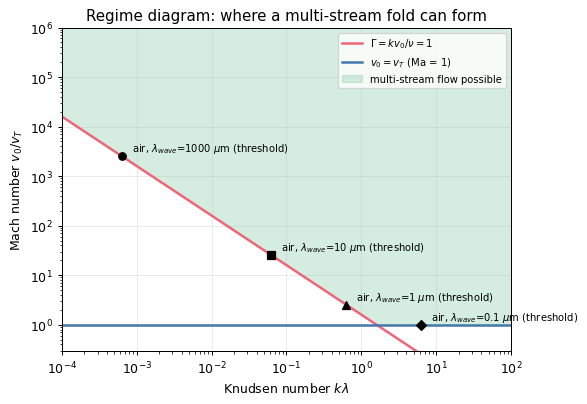

In [10]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
kl = np.logspace(-4, 2, 400)
vbar_over_vT = np.sqrt(8 / np.pi)
Ma_bound = np.maximum(vbar_over_vT / kl, 1.0)      # Gamma = Ma k lambda vT/vbar = 1
ax.loglog(kl, vbar_over_vT / kl, color="#ee6677", lw=2,
          label=r"$\Gamma = k v_0/\nu = 1$")
ax.axhline(1, color="#4477aa", lw=2, label=r"$v_0 = v_T$ (Ma = 1)")
ax.fill_between(kl, Ma_bound, 1e6, color="#88ccaa", alpha=0.35,
                label="multi-stream flow possible")
for L, mark in [(1e-3, "o"), (1e-5, "s"), (1e-6, "^"), (1e-7, "D")]:
    k = 2 * np.pi / L
    g = gas(**AIR)
    ax.plot(k * g["lam"], max(g["nu"] / k / g["vT"], 1.0), mark, color="k", ms=6)
    ax.annotate(rf"air, $\lambda_{{wave}}$={L*1e6:g} $\mu$m (threshold)",
                (k * g["lam"], max(g["nu"] / k / g["vT"], 1.0)),
                textcoords="offset points", xytext=(8, 4), fontsize=8)
ax.set(xlabel=r"Knudsen number $k\lambda$", ylabel=r"Mach number $v_0/v_T$",
       xlim=(1e-4, 1e2), ylim=(0.3, 1e6),
       title="Regime diagram: where a multi-stream fold can form")
ax.legend(fontsize=8, loc="upper right")
plt.show()

## 8. Which relative speed sets $\nu$, and how sharp is the criterion?

**Why $\bar v\sim v_T$ and not $v_0$ in the collision rate.** Collisions are driven by
*relative* velocities. Molecules meeting at the same point at time $t$ started within
$\sim v_Tt$ of each other, and over that distance the flow velocity varies only by
$v_0k\,(v_Tt)$. At $t\sim t_b=1/(kv_0)$ this is exactly $v_T$: the shear-induced spread of
relative velocities is comparable to the thermal one, never to $v_0$. So $\nu\sim n\sigma v_T$
throughout the steepening, and only *after* the streams have separated do relative velocities
$\sim v_0$ (and hence a much faster collision rate) appear — which is why a multi-stream state,
once formed, is short-lived.

Formally, from the exact solution the local velocity spread is
$\theta/|1+\tau\cos\eta|$ in units of $v_0$: it is $\sim\theta$ (i.e. $v_T$) everywhere except
in the immediate neighbourhood of the caustic.

**Sharpness.** Two competing corrections, both fractional powers of $\theta$:

* *Against* multi-stream: inside the fold the density is enhanced $\sim\varepsilon^{-1/2}\sim\theta^{-1/3}$
  and the local velocity spread is $\sim\varepsilon^{1/2}v_0\sim\theta^{1/3}v_0$, so the local
  collision rate there is $\nu_{\rm fold}\sim\nu\,\theta^{-1}$ — larger. It acts only during
  the fold-formation stage $\Delta t\sim\varepsilon_* t_b\sim\theta^{2/3}t_b$, giving
  $N_{\rm fold}\sim\theta^{-1/3}/\Gamma$.
* *For* multi-stream: a molecule that collides inside the fold is re-emitted into a velocity
  range $\sim\varepsilon^{1/2}v_0\gg v_T$, so it fills the narrow dip only with weight
  $\sim v_T/(\varepsilon^{1/2}v_0)\sim\theta^{2/3}$.

The two nearly cancel ($\theta^{-1/3}\cdot\theta^{2/3}=\theta^{1/3}$), leaving the threshold at
$\Gamma\sim\theta^{1/3}$–$1$. Since the problem only asks for an order of magnitude, the answer
stands as $\Gamma\gtrsim1$; the Monte Carlo below indeed puts the crossover at
$\Gamma\approx0.3$ — below, but within the factor of a few that an order-of-magnitude estimate
tolerates, and in the direction the argument above predicts.

In [11]:
for th in [0.05, 0.01]:
    eps = (1.5 * np.sqrt(np.log(2))) ** (2 / 3) * th ** (2 / 3)
    print(f"theta={th}: eps* = {eps:.4f}; in the fold: density x {eps ** -0.5:5.2f}, "
          f"velocity spread x {eps ** 0.5 / th:6.2f} (in units of v_T), "
          f"collision rate x {eps ** -0.5 * eps ** 0.5 / th:6.2f}, "
          f"dip-filling weight {th / eps ** 0.5:.3f}")
print("\n=> corrections are fractional powers of theta and pull in opposite directions;")
print("   the criterion Gamma ~ 1 is order-of-magnitude, as the problem allows.")

theta=0.05: eps* = 0.1574; in the fold: density x  2.52, velocity spread x   7.93 (in units of v_T), collision rate x  20.00, dip-filling weight 0.126
theta=0.01: eps* = 0.0538; in the fold: density x  4.31, velocity spread x  23.20 (in units of v_T), collision rate x 100.00, dip-filling weight 0.043

=> corrections are fractional powers of theta and pull in opposite directions;
   the criterion Gamma ~ 1 is order-of-magnitude, as the problem allows.


## 9. Numerical verification with a particle Monte Carlo

Two checks with $N$ macro-particles in $\xi\in[0,2\pi)$, initialised as
$V_i=\sin\xi_i+\theta\,\mathcal N(0,1)$ with $\xi_i$ uniform (uniform density, uniform
temperature, sinusoidal drift).

**(a) Collisionless.** Push exactly, $\xi\to\xi+V\tau$, and histogram $V$ in a thin slab
around $\xi=\pi$: it must reproduce the analytic $F$ above (three equal-height peaks).

tau=1.0:  142797 particles in the slab, max relative deviation from analytic (where f>5% of peak) = 0.171
tau=1.2:  144711 particles in the slab, max relative deviation from analytic (where f>5% of peak) = 0.085
tau=1.5:   56674 particles in the slab, max relative deviation from analytic (where f>5% of peak) = 0.188


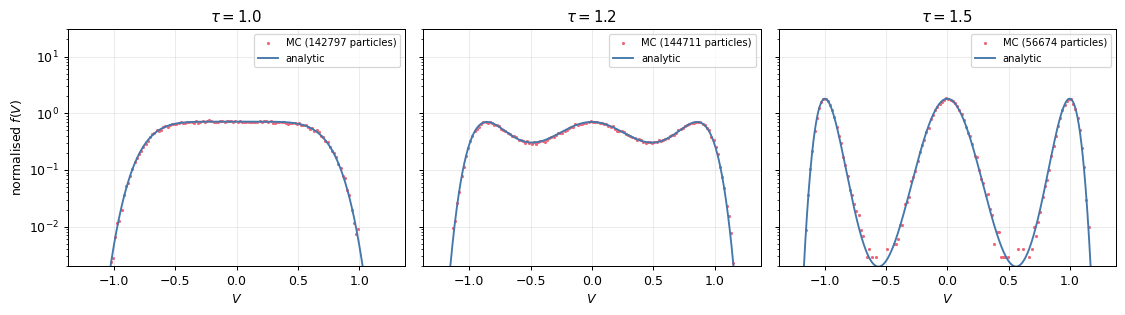

In [12]:
rng = np.random.default_rng(2024)
theta = 0.05
N = 4_000_000
xi0 = rng.random(N) * 2 * np.pi
V0 = np.sin(xi0) + theta * rng.standard_normal(N)

def slab_hist(xi, V, xc, half, bins=140, vr=(-1.25, 1.25)):
    m = np.abs((xi - xc + np.pi) % (2 * np.pi) - np.pi) < half
    h, e = np.histogram(V[m], bins=bins, range=vr, density=True)
    return 0.5 * (e[1:] + e[:-1]), h, int(m.sum())

fig, ax = plt.subplots(1, 3, figsize=(12.6, 3.6), sharey=True)
half = 0.01
for a, tau in zip(ax, [1.00, 1.20, 1.50]):
    xi = (xi0 + V0 * tau) % (2 * np.pi)
    c, h, cnt = slab_hist(xi, V0, np.pi, half)
    Vg = np.linspace(-1.25, 1.25, 3001)
    Fa = F(Vg, np.pi, tau, theta)
    Fa = Fa / np.trapezoid(Fa, Vg)
    a.plot(c, h, ".", ms=3, color="#ee6677", label=f"MC ({cnt} particles)")
    a.plot(Vg, Fa, color="#4477aa", lw=1.5, label="analytic")
    a.set(xlabel=r"$V$", yscale="log", ylim=(2e-3, 30), title=rf"$\tau={tau}$")
    a.legend(fontsize=8)
ax[0].set_ylabel("normalised $f(V)$")
plt.show()

for tau in [1.0, 1.2, 1.5]:
    xi = (xi0 + V0 * tau) % (2 * np.pi)
    c, h, cnt = slab_hist(xi, V0, np.pi, half)
    Vg = np.linspace(-1.25, 1.25, 6001)
    Fa = F(Vg, np.pi, tau, theta)
    Fa = Fa / np.trapezoid(Fa, Vg)
    ref = np.interp(c, Vg, Fa)
    good = ref > 0.05 * ref.max()
    err = np.abs(h[good] - ref[good]) / ref[good]
    print(f"tau={tau}: {cnt:7d} particles in the slab, "
          f"max relative deviation from analytic (where f>5% of peak) = {err.max():.3f}")

**(b) With collisions.** A full DSMC is unnecessary; the physics we are testing is only
"collisions relax $f$ towards the local Maxwellian at rate $\nu$", which is the BGK model.
So at every step each particle is, with probability $1-e^{-\nu\,\Delta t}$, given a fresh
velocity drawn from the Maxwellian built from the *local* (cell) density, mean velocity and
temperature. In dimensionless units the only parameter is

$$\hat\nu=\frac{\nu}{k v_0}=\frac1\Gamma .$$

We run to $\tau=1.5$ (a well-developed fold; $\varepsilon=0.5$) and measure the peak-to-dip
contrast in a thin slab at $\xi=\pi$. To keep the measurement free of histogram noise we do
*not* run a blind peak-finder on the counts; instead we evaluate the particle density at the
**velocities where the collisionless theory puts the three peaks and the two dips**
($V=0,\pm0.997$ and $V=\pm0.561$ at $\tau=1.5$, $\theta=0.05$) and take
$\min(\text{peaks})/\max(\text{dips})$. The prediction: contrast $\ge2$ for
$\Gamma\gtrsim1$, and a single-peaked (locally Maxwellian) distribution for $\Gamma\ll1$.

Caveats: BGK has one relaxation rate instead of a true velocity-dependent collision operator,
and it is 1D-in-velocity here; it fixes no numerical prefactors, only the location of the
crossover in $\Gamma$ to within a factor of a few.

In [13]:
def bgk_run(Gamma, theta=0.05, npart=1_000_000, dtau=0.0075, tau_end=1.5,
            ncell=128, seed=1):
    """Free streaming + stochastic BGK collisions, units 1/k, v0, 1/(k v0)."""
    rng = np.random.default_rng(seed)
    xi = rng.random(npart) * 2 * np.pi
    V = np.sin(xi) + theta * rng.standard_normal(npart)
    p = 1.0 - np.exp(-dtau / Gamma) if np.isfinite(Gamma) else 0.0
    for _ in range(int(round(tau_end / dtau))):
        xi = (xi + V * dtau) % (2 * np.pi)
        if p > 0.0:
            cell = np.minimum((xi / (2 * np.pi) * ncell).astype(np.int64), ncell - 1)
            cnt = np.bincount(cell, minlength=ncell).astype(float)
            s1 = np.bincount(cell, weights=V, minlength=ncell)
            s2 = np.bincount(cell, weights=V * V, minlength=ncell)
            cnt[cnt == 0] = 1.0
            mean = s1 / cnt
            var = np.maximum(s2 / cnt - mean ** 2, 1e-14)
            hit = rng.random(npart) < p
            idx = cell[hit]
            V[hit] = mean[idx] + np.sqrt(var[idx]) * rng.standard_normal(int(hit.sum()))
    return xi, V

def probe_points(tau, theta, xc=np.pi):
    """Velocities of the stream peaks and of the dips between them, from theory."""
    Vg = np.linspace(-1.3, 1.3, 400001)
    f = F(Vg, xc, tau, theta)
    d = np.diff(f)
    return (Vg[np.where((d[:-1] > 0) & (d[1:] <= 0))[0] + 1],
            Vg[np.where((d[:-1] < 0) & (d[1:] >= 0))[0] + 1])

def contrast(xi, V, Vpk, Vdp, xc=np.pi, half=np.pi / 64, w=0.03):
    """min(peak density)/max(dip density) at the theory-given velocities."""
    m = np.abs((xi - xc + np.pi) % (2 * np.pi) - np.pi) < half
    Vc = V[m]
    dens = lambda q: np.array([np.count_nonzero(np.abs(Vc - x) < w) / (2 * w) for x in q])
    pk, dp = dens(Vpk), dens(Vdp)
    return pk.min() / max(dp.max(), 1.0 / (2 * w)), Vc.size, pk, dp

Vpk, Vdp = probe_points(1.5, 0.05)
print(f"theory peak velocities {np.round(Vpk, 4)},  dip velocities {np.round(Vdp, 4)}")
print(f"analytic point contrast at xi = pi exactly: "
      f"{F(Vpk, np.pi, 1.5, 0.05).min() / F(Vdp, np.pi, 1.5, 0.05).max():.0f}\n")

GAMMAS = [np.inf, 30.0, 10.0, 3.0, 1.0, 0.3, 0.1, 0.03]
runs = {}
print(f"{'Gamma':>7} {'nu t_end':>9} {'N in slab':>10} {'contrast':>9} "
      f"{'multi-stream?':>14}")
for G in GAMMAS:
    xi, V = bgk_run(G)
    c, cnt, pk, dp = contrast(xi, V, Vpk, Vdp)
    m = np.abs((xi - np.pi + np.pi) % (2 * np.pi) - np.pi) < np.pi / 64
    hh, ee = np.histogram(V[m], bins=90, range=(-1.3, 1.3))
    runs[G] = (0.5 * (ee[1:] + ee[:-1]), hh.astype(float), c)
    print(f"{G:7.3g} {1.5 / G:9.3f} {cnt:10d} {c:9.2f} "
          f"{('YES' if c >= 2 else 'no'):>14}")

theory peak velocities [-0.9972  0.      0.9972],  dip velocities [-0.5607  0.5607]
analytic point contrast at xi = pi exactly: 915

  Gamma  nu t_end  N in slab  contrast  multi-stream?
    inf     0.000      69706    360.89            YES
     30     0.050      70061    183.46            YES
     10     0.150      70870     71.91            YES
      3     0.500      73680     26.55            YES
      1     1.500      79959      8.87            YES
    0.3     5.000      94469      1.76             no
    0.1    15.000     102574      0.38             no
   0.03    50.000      95820      0.37             no


contrast crosses 2 between Gamma = 0.3 and 1  ->  threshold Gamma_* = O(1), as predicted

time-step check: Gamma=1, dtau=0.01500 -> contrast   8.80
time-step check: Gamma=1, dtau=0.00750 -> contrast   8.65
time-step check: Gamma=1, dtau=0.00375 -> contrast   8.22
(the three agree to a few per cent: the result is time-step converged)


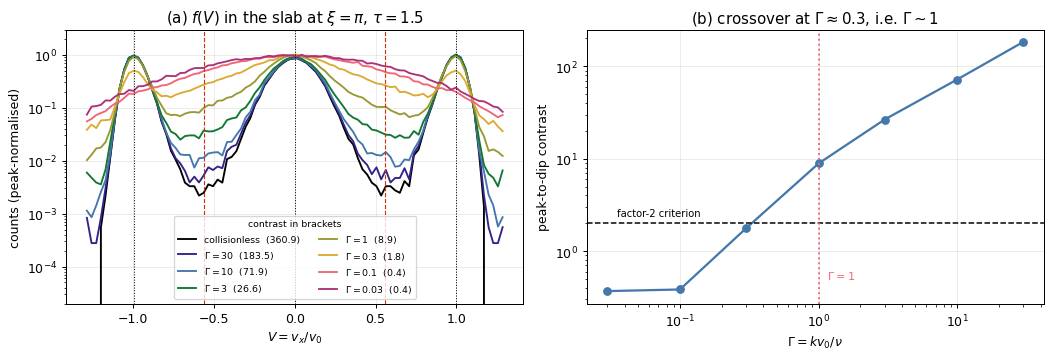

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11.8, 4.1))
cols = ["#000000", "#332288", "#4477aa", "#117733", "#999933", "#ddaa33",
        "#ee6677", "#aa3377"]
for (G, (ctr, h, c)), col in zip(runs.items(), cols):
    lab = "collisionless" if not np.isfinite(G) else rf"$\Gamma={G:g}$"
    ax[0].plot(ctr, h / h.max(), lw=1.5, color=col, label=lab + f"  ({c:.1f})")
for q in Vpk:
    ax[0].axvline(q, color="k", ls=":", lw=0.8)
for q in Vdp:
    ax[0].axvline(q, color="#cc3311", ls="--", lw=0.9)
ax[0].set(xlabel=r"$V=v_x/v_0$", ylabel="counts (peak-normalised)", yscale="log",
          ylim=(2e-5, 3),
          title=r"(a) $f(V)$ in the slab at $\xi=\pi$, $\tau=1.5$")
ax[0].legend(fontsize=7.5, loc="lower center", ncol=2, title="contrast in brackets",
             title_fontsize=7.5)

Gs = np.array([G for G in GAMMAS if np.isfinite(G)])
cs = np.array([runs[G][2] for G in Gs])
ax[1].loglog(Gs, cs, "o-", color="#4477aa", lw=1.8, ms=6)
ax[1].axhline(2, color="k", ls="--", lw=1.2)
ax[1].axvline(1, color="#ee6677", ls=":", lw=1.5)
ax[1].text(1.15, 0.5, r"$\Gamma=1$", color="#ee6677", fontsize=9)
ax[1].text(0.035, 2.4, "factor-2 criterion", fontsize=8)
ax[1].set(xlabel=r"$\Gamma=k v_0/\nu$", ylabel="peak-to-dip contrast",
          title=r"(b) crossover at $\Gamma\approx0.3$, i.e. $\Gamma\sim1$")
plt.show()

icross = np.searchsorted(cs[::-1], 2.0)
print(f"contrast crosses 2 between Gamma = {Gs[::-1][icross - 1]:g} and "
      f"{Gs[::-1][icross]:g}  ->  threshold Gamma_* = O(1), as predicted\n")
for dt in [0.015, 0.0075, 0.00375]:
    c = contrast(*bgk_run(1.0, dtau=dt, npart=500_000), Vpk, Vdp)[0]
    print(f"time-step check: Gamma=1, dtau={dt:7.5f} -> contrast {c:6.2f}")
print("(the three agree to a few per cent: the result is time-step converged)")

**Reading the scan.** The contrast falls monotonically with $\Gamma$ — from $\sim400$ in the
collisionless run (there the measured value is limited only by particle statistics and by the
finite slab width, not by physics) through $\sim9$ at $\Gamma=1$, to below $2$ at
$\Gamma=0.3$. For $\Gamma\le0.1$ the ratio drops *below 1*: the side maxima have vanished
altogether and $f$ is a single broad hump — the fold has been replaced by a hydrodynamic,
locally Maxwellian shock. The threshold therefore sits at $\Gamma_*\approx0.3$, i.e.
$\Gamma_*\sim1$, which is the whole content of the boxed answer.

## 10. Alternative solution 2 — two length scales, no kinetic equation

The whole problem can be done on one line of dimensional reasoning, plus one physical
insight. It gives the same answer and is worth keeping as the "back of the envelope" version.

**Step 1 — the only two rates in the problem.** The velocity field $v_0\sin kx$ deforms itself
by advection at rate $|\partial_x v_x|\sim k v_0$; that is the rate at which a compressive
region steepens into a fold, so the fold appears after $t_b\sim1/(kv_0)$. The gas erases any
non-Maxwellian feature at the collision rate $\nu\sim n\sigma v_T$. Multi-stream flow is a
non-Maxwellian feature produced by advection, so it exists iff

$$k v_0 \gtrsim \nu\sim n\sigma v_T\quad\Longrightarrow\quad
v_0\gtrsim\frac{n r^2}{k}\sqrt{\frac{k_BT}{m}} .$$

**Step 2 — the same statement as a length comparison (this is the insight).** Ask *how thick*
the structure is that the collisionless dynamics wants to build. Two streams can only be told
apart if their velocity difference exceeds the thermal width $v_T$; near the fold the velocity
difference across a distance $\delta$ is $\sim\delta\times|\partial_xv_x|\sim\delta kv_0$; so
the front sharpens down to

$$\delta\sim\frac{v_T}{k v_0}\qquad(\text{indeed }\Delta x_{\rm fold}\sim v_Tt_b\text{, as
derived exactly in §6}),$$

and it cannot get thinner, because thermal motion smears anything finer. Streams
interpenetrate only if a molecule can cross this front without colliding:

$$\lambda\gtrsim\delta\sim\frac{v_T}{kv_0}
\qquad\Longleftrightarrow\qquad
v_0\gtrsim\frac{v_T}{k\lambda}=\frac{n\sigma v_T}{k}\;\cdot\sqrt2 .$$

Same condition. In words: **multi-stream flow occurs when the incipient shock front is thinner
than a mean free path.** (If instead $\lambda\ll\delta$, the front is many mean free paths
thick, every fluid element inside it is in local equilibrium, and the fold is replaced by a
Navier–Stokes shock with a single-peaked $f$.) The Knudsen number *of the front*,
$\lambda/\delta=\mathrm{Ma}\cdot k\lambda\cdot(\bar v/v_T)^{-1}\cdot\ldots\sim\Gamma$, is the
control parameter — not the Knudsen number of the wavelength.

In [15]:
g = gas(**AIR)
print("cross-check that the two routes give the same number (air-like gas, L = 1 um):")
k = 2 * np.pi / 1e-6
v0 = 1.0e4
Gamma = k * v0 / g["nu"]
delta = g["vT"] / (k * v0)
print(f"  Gamma = k v0 / nu                = {Gamma:.4f}")
print(f"  fold thickness delta = v_T/(k v0) = {delta * 1e9:.3f} nm")
print(f"  mean free path lambda             = {g['lam'] * 1e9:.3f} nm")
print(f"  lambda / delta                    = {g['lam'] / delta:.4f}"
      f"  = Gamma x {g['lam'] / delta / Gamma:.4f}  (= v_bar/v_T = "
      f"{g['vbar'] / g['vT']:.4f})")
print("  -> the two criteria differ only by the O(1) factor v_bar/v_T = sqrt(8/pi).")

cross-check that the two routes give the same number (air-like gas, L = 1 um):
  Gamma = k v0 / nu                = 13.4085
  fold thickness delta = v_T/(k v0) = 4.675 nm
  mean free path lambda             = 100.035 nm
  lambda / delta                    = 21.3969  = Gamma x 1.5958  (= v_bar/v_T = 1.5958)
  -> the two criteria differ only by the O(1) factor v_bar/v_T = sqrt(8/pi).


## 11. A caveat worth knowing: collisional shocks are bimodal too

The estimate above answers the intended question — *when does a collisionless multi-stream
fold form?* Strictly, though, the factor-of-two test can also be passed inside a **fully
collisional strong shock**: the classic Mott-Smith picture (confirmed by DSMC) is that inside
the front $f$ is roughly a superposition of the upstream and downstream Maxwellians,

$$f\simeq(1-w)\,n_1\phi_1(v-u_1)+w\,n_2\phi_2(v-u_2),$$

which for $\mathrm{Ma}\gg1$ is visibly bimodal — a narrow cold peak plus a broad hot one —
over a region a few $\lambda$ thick. The cell below evaluates its contrast for a strong shock
($\gamma=5/3$: $n_2/n_1=4$, $u_2=u_1/4$, $k_BT_2=\frac{3}{16}mu_1^2$).

So the sharp statement is: for $\Gamma\gtrsim1$ one gets a *collisionless, multi-valued*
velocity field — two cold interpenetrating beams of comparable weight, which is what
"multi-stream flow" means; for $\Gamma\ll1$ one gets a hydrodynamic shock, whose interior can
still be weakly bimodal but which contains no distinct streams. Both readings share the same
physically interesting boundary, $kv_0\sim\nu$.

In [16]:
def mott_smith_contrast(Ma, w=0.5, gam=5 / 3.0):
    """Bimodal contrast inside a strong shock (two-Maxwellian ansatz), v in units of u1."""
    n2 = (gam + 1) * Ma ** 2 / ((gam - 1) * Ma ** 2 + 2)
    u2 = 1.0 / n2
    T1 = 1.0 / (gam * Ma ** 2)                       # kT1/(m u1^2)
    T2 = T1 * (2 * gam * Ma ** 2 - (gam - 1)) * ((gam - 1) * Ma ** 2 + 2) \
        / ((gam + 1) ** 2 * Ma ** 2)
    V = np.linspace(-0.6, 2.0, 400001)
    f = ((1 - w) / np.sqrt(2 * np.pi * T1) * np.exp(-(V - 1) ** 2 / (2 * T1))
         + w * n2 / np.sqrt(2 * np.pi * T2) * np.exp(-(V - u2) ** 2 / (2 * T2)))
    d = np.diff(f)
    imax = np.where((d[:-1] > 0) & (d[1:] <= 0))[0] + 1
    imin = np.where((d[:-1] < 0) & (d[1:] >= 0))[0] + 1
    if len(imax) < 2 or len(imin) < 1:
        return n2, u2, np.sqrt(T2), 1.0
    mid = imin[(imin > imax[0]) & (imin < imax[-1])]
    return n2, u2, np.sqrt(T2), min(f[imax[0]], f[imax[-1]]) / f[mid].min()

print(f"{'Ma':>5} {'n2/n1':>7} {'u2/u1':>7} {'v_T2/u1':>8} {'contrast':>9}")
for Ma in [2, 3, 5, 10, 30, 100]:
    n2, u2, vt2, c = mott_smith_contrast(Ma)
    print(f"{Ma:5g} {n2:7.3f} {u2:7.3f} {vt2:8.3f} {c:9.2f}")
print("\n(so a strong collisional shock is itself weakly bimodal - the estimate in this")
print(" notebook is the condition for genuine collisionless stream crossing.)")

   Ma   n2/n1   u2/u1  v_T2/u1  contrast
    2   2.286   0.437    0.558      1.00
    3   3.000   0.333    0.494      1.00
    5   3.571   0.280    0.456      1.28
   10   3.883   0.258    0.439      1.94
   30   3.987   0.251    0.434      3.08
  100   3.999   0.250    0.433      3.91

(so a strong collisional shock is itself weakly bimodal - the estimate in this
 notebook is the condition for genuine collisionless stream crossing.)


## 12. Summary

| quantity | result |
|---|---|
| exact collisionless $f$ | $f=\dfrac{n}{\sqrt{2\pi}v_T}\exp\!\left[-\dfrac{(v_x-v_0\sin k(x-v_xt))^2}{2v_T^2}\right]$ |
| breaking (fold) time | $t_b=1/(kv_0)$, at $x=\pi/k$ |
| fold half-width in $kx$ | $A(\tau)=\sqrt{\tau^2-1}-\arccos(1/\tau)\simeq\frac{2\sqrt2}{3}(\tau-1)^{3/2}$ |
| dip depth in $f$ | $F_{\max}/F_{\min}=\exp\!\big(H_{\rm ext}^2/2\theta^2\big)$, $H_{\rm ext}=(X\mp A)/\tau$ |
| factor-2 criterion met at | $\tau_*=1+O(\theta^{2/3})$, i.e. $t_*\simeq t_b$ |
| fold thickness then | $\Delta x\sim v_T/(kv_0)=v_Tt_b$ |
| collisions allowed | $\nu t_*\lesssim1$ |

$$\textbf{Condition: }\;
v_0\;\gtrsim\;\frac{\nu}{k}\;\sim\;\frac{n\sigma v_T}{k}\;\sim\;\frac{n r^{2}}{k}\sqrt{\frac{k_BT}{m}}
\qquad\Big(\Longleftrightarrow\ \mathrm{Ma}\cdot k\lambda\gtrsim1\Big)$$

and, since $v_0\gg v_T$ was assumed, altogether
$v_0\gg v_T\max\left(1,\,1/(k\lambda)\right)$.

**Assumptions and limits.** (i) 1D geometry, no external forces, hard spheres, so
$\sigma=4\pi r^2$ and $\nu=\sqrt2 n\sigma\bar v$; (ii) the criterion is order-of-magnitude —
keeping hard-sphere prefactors would multiply the right-hand side by $\approx28$, while the
fold-region corrections of §8 pull the threshold down by $\theta^{1/3}$; the Monte Carlo puts
the crossover at $\Gamma\approx0.3$; (iii) the multi-stream state is transient: once the
streams separate, their relative velocity is $\sim v_0$ and the local collision rate jumps to
$\sim n\sigma v_0=\nu\,\mathrm{Ma}$, so the fold is wiped out after $\sim\Gamma/\mathrm{Ma}$
breaking times unless $\Gamma\gtrsim\mathrm{Ma}$; (iv) for air at 1 atm the condition is
practically unreachable for wavelengths above a micron ($v_0\gtrsim10^5$ m/s), which is why
stream crossing is a rarefied-gas / short-wavelength phenomenon.